# 🔍 UPI Transaction Fraud Detection — SimpleRNN (Keras/TensorFlow)

### Dataset Summary
| Property | Value |
|---|---|
| Total transactions | 151,668 |
| Unique users | 1,000 |
| Fraud rate | 2.06% (3,131 fraud / 148,537 legit) |
| Class imbalance ratio | ~47:1 |
| Date range | Jan 1 – Mar 29, 2025 |
| Prediction mode | Batch |
| Primary metric | F1 Score (balanced) |

### Pipeline
1. Setup & Imports
2. Load & Validate Data
3. Preprocessing & Feature Engineering
4. Sequence Construction (per user)
5. Train / Val / Test Split
6. Build SimpleRNN Model
7. Train with Class Imbalance Handling
8. Training Curves
9. Optimal Threshold Tuning
10. Full Evaluation on Test Set
11. Batch Prediction
12. Save Model & Artifacts

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Adjust this path to where you saved your file in Google Drive
file_path = '/content/drive/My Drive/Colab Notebooks/upi-data-fe-01-02-03-04-05-06-07-08-09-10-11.csv'

df = pd.read_csv(file_path)
print(df.shape)
display(df.head())

(151668, 30)


,timestamp,time_since_last_tx,user_upi_id,receiver_upi_id,amount,transaction_type,status,sender_bank,receiver_bank,device_type,...,amount_zscore,user_mean_amount,user_std_amount,is_amount_spike,distance_from_prev_tx,is_location_jump,device_changed,isp_changed,tx_count_last_1hr,days_since_first_tx_with_receiver
0,2025-01-01 22:32:33,0.0,user0_4876@ybl,user4481@okbank,2576.19,P2P,SUCCESS,SBI,Union Bank of India,Android,...,-0.174238,4337.794729,10110.321339,0,0.0,0,0,0,1.0,0
1,2025-01-03 04:16:36,107043.0,user0_4876@ybl,user9029@okbank,2224.54,P2P,SUCCESS,SBI,Union Bank of India,Android,...,-0.209020,4337.794729,10110.321339,0,0.0,0,0,0,1.0,0
2,2025-01-04 00:45:48,73752.0,user0_4876@ybl,user5433@okbank,1709.67,P2M,SUCCESS,Axis Bank,Jana Small Finance Bank,Android,...,-0.259945,4337.794729,10110.321339,0,0.0,0,0,0,1.0,0
3,2025-01-04 01:16:19,1831.0,user0_4876@ybl,user1341@okbank,1666.03,Recharge,SUCCESS,Axis Bank,AU Small Finance Bank,Android,...,-0.264261,4337.794729,10110.321339,0,0.0,0,0,0,2.0,0
4,2025-01-07 02:15:54,262775.0,user0_4876@ybl,user2685@okbank,3313.15,P2P,SUCCESS,SBI,Karur Vysya Bank,Android,...,-0.101346,4337.794729,10110.321339,0,0.0,0,0,0,1.0,0


---
## 1. 🛠️ Setup & Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
# from tensorflow.keras import layers, callbacks
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout, LSTM
from tensorflow.keras.initializers import Constant

# Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score,
    precision_recall_curve, average_precision_score,
    roc_curve,
    precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(gpus) > 0}')
if gpus:
    print(f'GPU device         : {gpus[0].name}')

TensorFlow version : 2.19.0
GPU available      : False


In [ ]:
# def binary_focal_loss(gamma=2.0, alpha=0.25):
#     """
#     Focal Loss for binary classification.

#     gamma : focusing parameter — higher = more focus on hard examples
#             0.0 = standard cross-entropy
#             2.0 = recommended for fraud detection
#     alpha : weight for the positive (fraud) class [0, 1]
#             0.25 = default, tune between 0.25 - 0.75
#     """
#     def focal_loss_fn(y_true, y_pred):
#         y_true = tf.cast(y_true, tf.float32)
#         y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)  # numerical stability

#         # Standard cross-entropy terms
#         bce_1 = -y_true * tf.math.log(y_pred)           # fraud term
#         bce_0 = -(1 - y_true) * tf.math.log(1 - y_pred) # legit term

#         # Focal weights — suppress easy examples
#         p_t   = y_true * y_pred + (1 - y_true) * (1 - y_pred)
#         focal_weight = tf.pow(1.0 - p_t, gamma)

#         # Alpha balancing
#         alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)

#         loss = alpha_t * focal_weight * (bce_1 + bce_0)
#         return tf.reduce_mean(loss)

#     return focal_loss_fn

---
## 2. 📂 Load & Validate Data

In [12]:

# ─── UPDATE THIS PATH ────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/My Drive/Colab Notebooks/upi-data-fe-01-02-03-04-05-06-07-08-09-10-11.csv'   # <-- update to your actual file path
LABEL_COL = 'is_fraud'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values(['user_upi_id', 'timestamp']).reset_index(drop=True)

print(f'Shape         : {df.shape}')
print(f'Date range    : {df.timestamp.min()} to {df.timestamp.max()}')
print(f'Unique users  : {df.user_upi_id.nunique()}')
print(f'Fraud rate    : {df[LABEL_COL].mean()*100:.2f}%')
print(f'\nFraud counts:')
print(df[LABEL_COL].value_counts())

Shape         : (151668, 30)
Date range    : 2025-01-01 00:01:47 to 2025-03-29 23:58:46
Unique users  : 1000
Fraud rate    : 2.06%

Fraud counts:
is_fraud
0    148537
1      3131
Name: count, dtype: int64


In [13]:
# Validation checks
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])

# Confirm device_changed is all zeros — we will drop it
print(f'\ndevice_changed unique values: {df["device_changed"].unique()}')

# Key insight: status vs fraud
print(f'\nFraud rate by status (FAILED = 11.4% fraud!):')
print(df.groupby('status')[LABEL_COL].mean().round(4))

# Key insight: transaction_type vs fraud
print(f'\nFraud rate by transaction_type (P2P = 2.8% fraud):')
print(df.groupby('transaction_type')[LABEL_COL].mean().round(4))

=== Missing Values ===
merchant_id          121460
merchant_category    121460
dtype: int64

device_changed unique values: [0]

Fraud rate by status (FAILED = 11.4% fraud!):
status
FAILED     0.1139
SUCCESS    0.0185
Name: is_fraud, dtype: float64

Fraud rate by transaction_type (P2P = 2.8% fraud):
transaction_type
Bill Payment    0.0087
P2M             0.0099
P2P             0.0280
Recharge        0.0092
Name: is_fraud, dtype: float64


---
## 3. 🔧 Preprocessing & Feature Engineering

In [14]:
# 1. Drop zero-variance column
# device_changed = all zeros, no predictive value
df.drop(columns=['device_changed'], inplace=True)
print('Dropped: device_changed (all zeros)')

Dropped: device_changed (all zeros)


In [15]:
# 2. Fill merchant nulls
# Only P2M transactions (30,208 rows) have merchant info
# All others get 'none'
df['merchant_id']       = df['merchant_id'].fillna('none')
df['merchant_category'] = df['merchant_category'].fillna('none')
print('Filled merchant_id and merchant_category nulls with none')

Filled merchant_id and merchant_category nulls with none


In [16]:
# 3. Temporal features from timestamp
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['is_night']    = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
print('Added: hour, day_of_week, is_weekend, is_night')

Added: hour, day_of_week, is_weekend, is_night


In [17]:
# 4. Encode categorical columns
# Note: merchant_id has too many unique values — use merchant_category instead
cat_cols = ['transaction_type', 'status', 'sender_bank',
            'receiver_bank', 'device_type', 'merchant_category']

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'Encoded {col:25s} -> {df[col].nunique()} unique values')

Encoded transaction_type          -> 4 unique values
Encoded status                    -> 2 unique values
Encoded sender_bank               -> 24 unique values
Encoded receiver_bank             -> 24 unique values
Encoded device_type               -> 2 unique values
Encoded merchant_category         -> 10 unique values


In [18]:
# 5. Per-user rolling features (no data leakage — shift(1) excludes current row)
df['rolling_mean_amount'] = (
    df.groupby('user_upi_id')['amount']
    .transform(lambda x: x.shift(1).expanding().mean().fillna(x.mean()))
)
df['rolling_std_amount'] = (
    df.groupby('user_upi_id')['amount']
    .transform(lambda x: x.shift(1).expanding().std().fillna(x.std()))
)
df['amount_vs_personal_mean'] = df['amount'] - df['rolling_mean_amount']
df['user_tx_rank'] = df.groupby('user_upi_id').cumcount()
print('Added: rolling_mean_amount, rolling_std_amount, amount_vs_personal_mean, user_tx_rank')

Added: rolling_mean_amount, rolling_std_amount, amount_vs_personal_mean, user_tx_rank


In [ ]:
# 1. Drop zero-variance column
# device_changed = all zeros, no predictive value
# df.drop(columns=['device_changed'], inplace=True)
# print('Dropped: device_changed (all zeros)')

# # 2. Fill merchant nulls
# # Only P2M transactions (30,208 rows) have merchant info
# # All others get 'none'
# df['merchant_id']       = df['merchant_id'].fillna('none')
# df['merchant_category'] = df['merchant_category'].fillna('none')
# print('Filled merchant_id and merchant_category nulls with none')

# # 3. Temporal features from timestamp
# df['hour']        = df['timestamp'].dt.hour
# df['day_of_week'] = df['timestamp'].dt.dayofweek
# df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
# df['is_night']    = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
# print('Added: hour, day_of_week, is_weekend, is_night')

# # 4. Encode categorical columns
# # Note: merchant_id has too many unique values — use merchant_category instead
# cat_cols = ['transaction_type', 'status', 'sender_bank',
#             'receiver_bank', 'device_type', 'merchant_category']

# label_encoders = {}
# for col in cat_cols:
#     le = LabelEncoder()
#     df[col + '_enc'] = le.fit_transform(df[col].astype(str))
#     label_encoders[col] = le
#     print(f'Encoded {col:25s} -> {df[col].nunique()} unique values')

# # 5. Per-user rolling features (no data leakage — shift(1) excludes current row)
# df['rolling_mean_amount'] = (
#     df.groupby('user_upi_id')['amount']
#     .transform(lambda x: x.shift(1).expanding().mean().fillna(x.mean()))
# )
# df['rolling_std_amount'] = (
#     df.groupby('user_upi_id')['amount']
#     .transform(lambda x: x.shift(1).expanding().std().fillna(x.std()))
# )
# df['amount_vs_personal_mean'] = df['amount'] - df['rolling_mean_amount']
# df['user_tx_rank'] = df.groupby('user_upi_id').cumcount()
# print('Added: rolling_mean_amount, rolling_std_amount, amount_vs_personal_mean, user_tx_rank')

In [19]:
# Define final feature set

ORIGINAL_NUMERIC = [
    'amount',
    'time_since_last_tx',
    'amount_zscore',
    'user_mean_amount',
    'user_std_amount',
    'tx_count_last_5min',
    'tx_count_last_1hr',
    'amount_ratio_prev',
    'is_amount_spike',
    'distance_from_prev_tx',
    'is_location_jump',
    'isp_changed',
    'days_since_first_tx_with_receiver',
    'latitude',
    'longitude',
]

ENGINEERED_NUMERIC = [
    'hour',
    'day_of_week',
    'is_weekend',
    'is_night',
    'rolling_mean_amount',
    'rolling_std_amount',
    'amount_vs_personal_mean',
    'user_tx_rank',
]

ENCODED_CATS = [c + '_enc' for c in cat_cols]

FEATURE_COLS = ORIGINAL_NUMERIC + ENGINEERED_NUMERIC + ENCODED_CATS

# Verify all exist
missing_cols = [f for f in FEATURE_COLS if f not in df.columns]
if missing_cols:
    print(f'WARNING - missing columns: {missing_cols}')
else:
    print(f'All {len(FEATURE_COLS)} features verified OK')
    for i, f in enumerate(FEATURE_COLS, 1):
        print(f'  {i:2d}. {f}')

All 29 features verified OK
   1. amount
   2. time_since_last_tx
   3. amount_zscore
   4. user_mean_amount
   5. user_std_amount
   6. tx_count_last_5min
   7. tx_count_last_1hr
   8. amount_ratio_prev
   9. is_amount_spike
  10. distance_from_prev_tx
  11. is_location_jump
  12. isp_changed
  13. days_since_first_tx_with_receiver
  14. latitude
  15. longitude
  16. hour
  17. day_of_week
  18. is_weekend
  19. is_night
  20. rolling_mean_amount
  21. rolling_std_amount
  22. amount_vs_personal_mean
  23. user_tx_rank
  24. transaction_type_enc
  25. status_enc
  26. sender_bank_enc
  27. receiver_bank_enc
  28. device_type_enc
  29. merchant_category_enc


In [20]:
# Scale all features to zero mean, unit variance
scaler = StandardScaler()
# Separate binary flags from continuous features
BINARY_FLAGS = [
    'is_amount_spike',
    'is_location_jump',
    'is_weekend',
    'is_night',
    'isp_changed',
]

CONTINUOUS_FEATURES = [f for f in FEATURE_COLS if f not in BINARY_FLAGS]

# Scale ONLY continuous features
df[CONTINUOUS_FEATURES] = scaler.fit_transform(df[CONTINUOUS_FEATURES].fillna(0))

# Keep binary flags as-is (0 or 1)
print(f'\n✅ Scaled {len(CONTINUOUS_FEATURES)} continuous features')
print(f'✅ Preserved {len(BINARY_FLAGS)} binary flags')




✅ Scaled 24 continuous features
✅ Preserved 5 binary flags


In [ ]:
output_file_path = '/content/drive/My Drive/Colab Notebooks/Final Models/Dataset/processed_upi_data_43Col.csv'
df.to_csv(output_file_path, index=False)
print(f'DataFrame saved to: {output_file_path}')

In [ ]:
df.head()

,timestamp,time_since_last_tx,user_upi_id,receiver_upi_id,amount,transaction_type,status,sender_bank,receiver_bank,device_type,...,transaction_type_enc,status_enc,sender_bank_enc,receiver_bank_enc,device_type_enc,merchant_category_enc,rolling_mean_amount,rolling_std_amount,amount_vs_personal_mean,user_tx_rank
0,2025-01-01 22:32:33,-0.943697,user0_4876@ybl,user4481@okbank,-0.156331,P2P,SUCCESS,SBI,Union Bank of India,Android,...,0.384304,0.150403,1.087325,1.518369,-0.974827,0.431981,0.116801,0.286542,-0.175084,-1.697811
1,2025-01-03 04:16:36,1.126869,user0_4876@ybl,user9029@okbank,-0.191892,P2P,SUCCESS,SBI,Union Bank of India,Android,...,0.384304,0.150403,1.087325,1.518369,-0.974827,0.431981,-0.840384,0.286542,-0.034888,-1.675429
2,2025-01-04 00:45:48,0.482911,user0_4876@ybl,user5433@okbank,-0.243960,P2M,SUCCESS,Axis Bank,Jana Small Finance Bank,Android,...,-0.902659,0.150403,-1.527950,0.363010,-0.974827,-0.861974,-0.935920,-2.066975,-0.068600,-1.653047
3,2025-01-04 01:16:19,-0.908280,user0_4876@ybl,user1341@okbank,-0.248373,Recharge,SUCCESS,Axis Bank,AU Small Finance Bank,Android,...,1.671266,0.150403,-1.527950,-1.658870,-0.974827,0.431981,-1.061019,-2.022308,-0.050047,-1.630666
4,2025-01-07 02:15:54,4.139242,user0_4876@ybl,user2685@okbank,-0.081803,P2P,SUCCESS,SBI,Karur Vysya Bank,Android,...,0.384304,0.150403,1.087325,0.507430,-0.974827,0.431981,-1.129496,-2.022248,0.126261,-1.608284


---
## 4. 🔗 Sequence Construction (Per User)

> For each transaction, the model sees the **previous SEQ_LEN=10 transactions** from the same user.
> This allows the RNN to detect deviations from a user's own normal behaviour pattern.
>
> With 1,000 users averaging 152 transactions and SEQ_LEN=10,
> we generate approximately 141,000 sequences.

In [21]:
SEQ_LEN = 20

def build_sequences(df, feature_cols, label_col, seq_len):
    """
    Build (X, y) pairs grouped by user.
    For transaction at index i:
        X = feature matrix of transactions[i-seq_len : i]  shape: (seq_len, n_features)
        y = fraud label of transaction at index i
    """
    X_list, y_list = [], []

    for user_id, group in df.groupby('user_upi_id', sort=False):
        feats  = group[feature_cols].values.astype(np.float32)
        labels = group[label_col].values.astype(np.int32)

        if len(feats) <= seq_len:
            continue  # skip users with fewer txs than seq_len

        for i in range(seq_len, len(feats)):
            X_list.append(feats[i - seq_len : i])
            y_list.append(labels[i])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)


print('Building sequences...')
X, y = build_sequences(df, FEATURE_COLS, LABEL_COL, SEQ_LEN)

print(f'X shape  : {X.shape}  ->  (sequences, seq_len={SEQ_LEN}, features={len(FEATURE_COLS)})')
print(f'y shape  : {y.shape}')
print(f'Fraud    : {y.sum():,} ({y.mean()*100:.2f}%)')
print(f'Legit    : {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)')

Building sequences...
X shape  : (131668, 20, 29)  ->  (sequences, seq_len=20, features=29)
y shape  : (131668,)
Fraud    : 2,742 (2.08%)
Legit    : 128,926 (97.92%)


In [22]:
print(FEATURE_COLS)

['amount', 'time_since_last_tx', 'amount_zscore', 'user_mean_amount', 'user_std_amount', 'tx_count_last_5min', 'tx_count_last_1hr', 'amount_ratio_prev', 'is_amount_spike', 'distance_from_prev_tx', 'is_location_jump', 'isp_changed', 'days_since_first_tx_with_receiver', 'latitude', 'longitude', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'rolling_mean_amount', 'rolling_std_amount', 'amount_vs_personal_mean', 'user_tx_rank', 'transaction_type_enc', 'status_enc', 'sender_bank_enc', 'receiver_bank_enc', 'device_type_enc', 'merchant_category_enc']


In [ ]:
# Create a new DataFrame with only the 29 specified features, plus identifiers and label
df_features = df[['user_upi_id', 'timestamp', 'is_fraud'] + FEATURE_COLS ].copy()

print(f'New DataFrame shape: {df_features.shape}')
display(df_features.head())

output_file_path = '/content/drive/My Drive/Colab Notebooks/Final Models/Dataset/processed_final_data_29_03Col.csv'
df.to_csv(output_file_path, index=False)
print(f'DataFrame saved to: {output_file_path}')

---
## 5. ✂️ Train / Validation / Test Split

In [23]:
# Stratified splits preserve 2.06% fraud ratio in every set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

print(f'{"Split":<8} {"Samples":>10} {"Fraud":>8} {"Fraud%":>8}')
print('-' * 38)
for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f'{name:<8} {len(yy):>10,} {yy.sum():>8,} {yy.mean()*100:>7.2f}%')

Split       Samples    Fraud   Fraud%
--------------------------------------
Train        89,533    1,865    2.08%
Val          15,801      329    2.08%
Test         26,334      548    2.08%


In [24]:
# # Compute class weights to handle 47:1 imbalance
# class_weights_arr = compute_class_weight(
#     class_weight='balanced',
#     classes=np.array([0, 1]),
#     y=y_train
# )
# class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}

# print(f'Class weights:')
# print(f'  Legit (0) : {class_weights_arr[0]:.4f}')
# print(f'  Fraud (1) : {class_weights_arr[1]:.4f}')
# print(f'  Fraud is penalized {class_weights_arr[1]/class_weights_arr[0]:.1f}x more than Legit')

---
## 6. 🧠 Build SimpleRNN Model

Architecture: `Input -> SimpleRNN(128) -> Dropout -> SimpleRNN(64) -> Dropout -> Dense(32) -> Sigmoid`

In [25]:
@tf.keras.utils.register_keras_serializable()
def focal_loss_fn(y_true, y_pred):
    gamma = 2.0
    alpha = 0.75
    y_true  = tf.cast(y_true, tf.float32)
    y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce     = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
    p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    alpha_t = y_true * alpha  + (1 - y_true) * (1 - alpha)
    loss    = alpha_t * tf.pow(1.0 - p_t, gamma) * bce
    return tf.reduce_mean(loss)

In [ ]:
# NUM_FEATURES = len(FEATURE_COLS)

# def build_rnn_model(seq_len, num_features,
#                     rnn_units_1=128,
#                     rnn_units_2=64,
#                     dense_units=32,
#                     dropout_rate=0.3,
#                     learning_rate=1e-3):
#     """
#     Two-layer stacked SimpleRNN for fraud detection.
#     Input  : (batch, seq_len, num_features)
#     Output : (batch, 1) -> fraud probability [0, 1]
#     """
#     model = keras.Sequential([

#         # Layer 1: SimpleRNN — return_sequences=True to stack with next RNN
#         layers.SimpleRNN(
#             units            = rnn_units_1,
#             activation       = 'tanh',
#             return_sequences = True,
#             input_shape      = (seq_len, num_features),
#             name             = 'rnn_1'
#         ),
#         layers.Dropout(dropout_rate, name='dropout_1'),

#         # Layer 2: SimpleRNN — return_sequences=False, output final hidden state only
#         layers.SimpleRNN(
#             units            = rnn_units_2,
#             activation       = 'tanh',
#             return_sequences = False,
#             name             = 'rnn_2'
#         ),
#         layers.Dropout(dropout_rate, name='dropout_2'),

#         # Dense classification head
#         layers.Dense(dense_units, activation='relu', name='dense_1'),
#         layers.Dropout(dropout_rate / 2, name='dropout_3'),

#         # Output: sigmoid -> fraud probability
#         layers.Dense(1, activation='sigmoid', name='output')

#     ], name='UPI_Fraud_SimpleRNN')

#     model.compile(
#         optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
#         loss      = binary_focal_loss(gamma=2.0, alpha=0.25),  # <-- focal loss
#         metrics   = [
#             keras.metrics.AUC(name='auc', curve='PR'),
#             keras.metrics.Precision(name='precision'),
#             keras.metrics.Recall(name='recall'),
#         ]
#     )

#     # model.compile(
#     #     optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
#     #     loss      = 'binary_crossentropy',
#     #     metrics   = [
#     #         keras.metrics.AUC(name='auc', curve='PR'),  # Precision-Recall AUC
#     #         keras.metrics.Precision(name='precision'),
#     #         keras.metrics.Recall(name='recall'),
#     #     ]
#     # )
#     return model


# model = build_rnn_model(SEQ_LEN, NUM_FEATURES)
# model.summary()

In [26]:
# ── Initial bias — calibrates model to 2.06% fraud rate from epoch 1 ─────────
neg, pos     = np.bincount(y_train.flatten())
initial_bias = np.log([pos / neg])
print(f'Class counts : Legit={neg:,}  |  Fraud={pos:,}')
print(f'Initial bias : {initial_bias[0]:.4f}')

# ── Build model ───────────────────────────────────────────────────────────────
model = Sequential(name='UPI_Fraud_SimpleRNN')

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# model.add(
#     SimpleRNN(
#         units            = 256,
#         activation       = 'tanh',
#         return_sequences = False,
#         name             = 'rnn_1'
#     )
# )

# model.add(
#     SimpleRNN(
#         units            = 64,
#         activation       = 'tanh',
#         return_sequences = False,
#         name             = 'rnn_2'
#     )
# )
model.add(LSTM(32, return_sequences=False, name='lstm_1'))

# model.add(Dense(128, activation='relu', name='dense_1'))

model.add(Dense(16, activation='relu', name='dense_1'))   # add hidden layer back
model.add(Dropout(0.3, name='dropout_1'))
model.add(
    Dense(
        units            = 1,
        activation       = 'sigmoid',
        bias_initializer = Constant(initial_bias),
        name             = 'output'
    )
)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0005),
    loss      = focal_loss_fn,
    metrics   = [
        keras.metrics.AUC(name='auc', curve='PR'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

model.summary()

Class counts : Legit=87,668  |  Fraud=1,865
Initial bias : -3.8503


Model: "UPI_Fraud_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,481 (33.13 KB)

 Trainable params: 8,481 (33.13 KB)

 Non-trainable params: 0 (0.00 B)

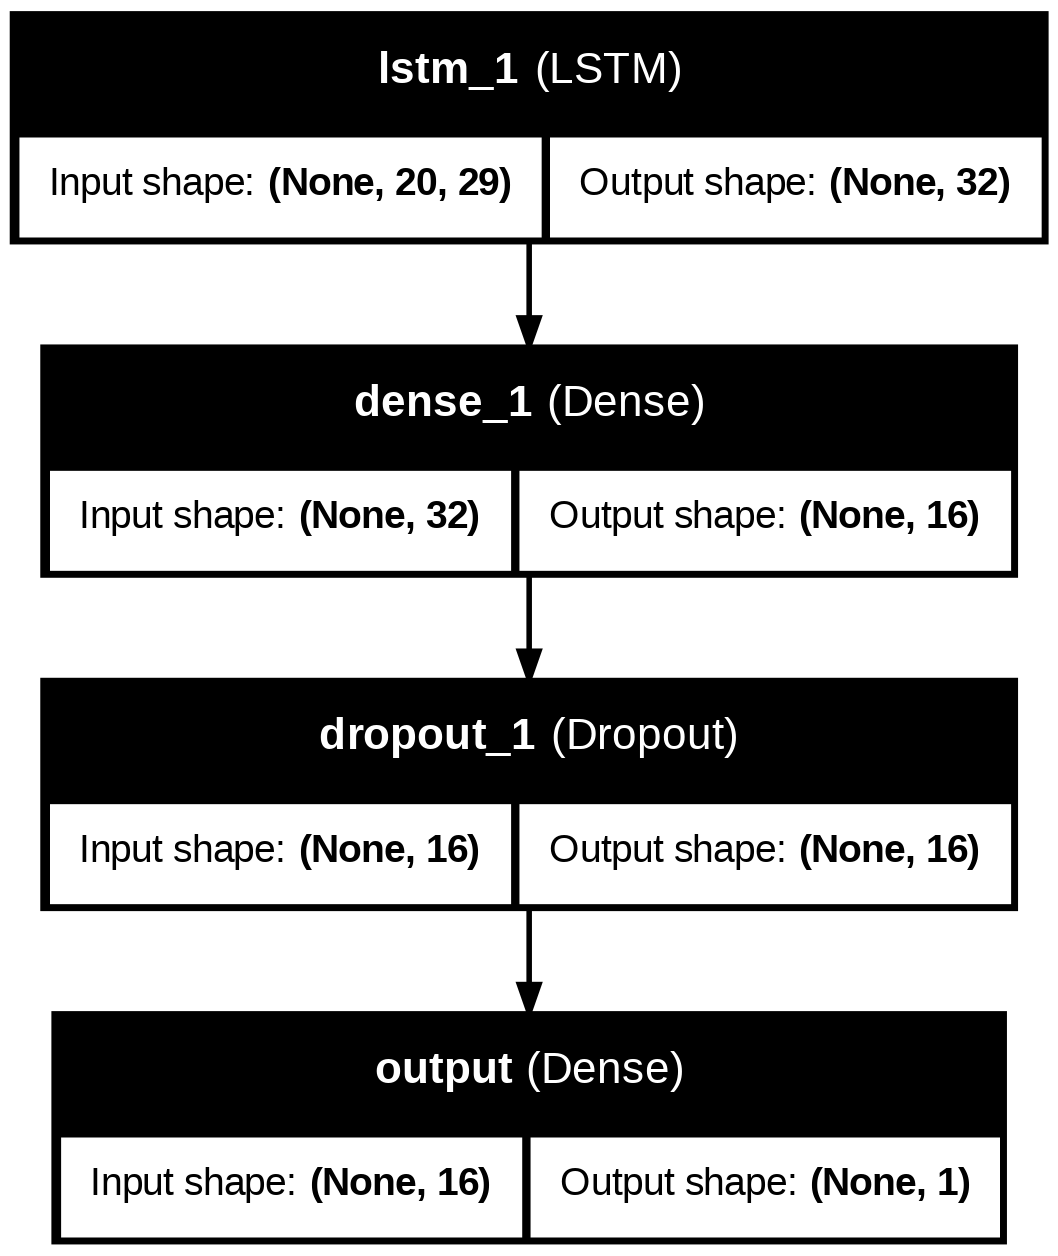

In [27]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model_architecture.png',
           show_shapes=True, show_layer_names=True)

---
## 7. 🏋️ Train the Model

In [28]:
# Callback 1: Save best model by val PR-AUC
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath       = 'best_fraud_rnn.keras',
    monitor        = 'val_auc',
    mode           = 'max',
    save_best_only = True,
    verbose        = 1
)

# Callback 2: Early stopping — stop if val_auc stagnates for 7 epochs
earlystop_cb = callbacks.EarlyStopping(
    monitor              = 'val_auc',
    mode                 = 'max',
    patience             = 10,
    restore_best_weights = True,
    verbose              = 1
)

# Callback 3: Halve learning rate after 3 stagnant epochs
reducelr_cb = callbacks.ReduceLROnPlateau(
    monitor  = 'val_auc',
    mode     = 'max',
    factor   = 0.5,
    patience = 3,
    min_lr   = 1e-6,
    verbose  = 1
)

print('Callbacks ready:')
print('  ModelCheckpoint   -> saves best model (val PR-AUC)')
print('  EarlyStopping     -> stops after 7 epochs without improvement')
print('  ReduceLROnPlateau -> halves LR after 3 stagnant epochs')

Callbacks ready:
  ModelCheckpoint   -> saves best model (val PR-AUC)
  EarlyStopping     -> stops after 7 epochs without improvement
  ReduceLROnPlateau -> halves LR after 3 stagnant epochs


In [29]:
from tensorflow.keras.utils import Sequence

class FraudBalancedGenerator(Sequence):
    def __init__(self, X, y, batch_size=256, fraud_ratio=0.15, seed=42):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.fraud_ratio = fraud_ratio
        self.rng = np.random.default_rng(seed)

        self.fraud_idx = np.where(y == 1)[0]
        self.legit_idx = np.where(y == 0)[0]

        self.n_fraud = max(1, int(batch_size * fraud_ratio))
        self.n_legit = batch_size - self.n_fraud

        print(f'✅ Stratified batching enabled:')
        print(f'   Per batch: {self.n_legit} legit + {self.n_fraud} fraud')
        print(f'   Total fraud: {len(self.fraud_idx):,}')
        print(f'   Total legit: {len(self.legit_idx):,}')

    def __len__(self):
        return len(self.legit_idx) // self.n_legit

    def __getitem__(self, idx):
        fraud_batch = self.rng.choice(self.fraud_idx, self.n_fraud, replace=True)
        legit_start = idx * self.n_legit
        legit_end = legit_start + self.n_legit
        legit_batch = self.legit_idx[legit_start:legit_end]

        batch_idx = np.concatenate([fraud_batch, legit_batch])
        self.rng.shuffle(batch_idx)

        return self.X[batch_idx], self.y[batch_idx]

    def on_epoch_end(self):
        self.rng.shuffle(self.legit_idx)

# Create generator
train_gen = FraudBalancedGenerator(X_train, y_train, batch_size=256, fraud_ratio=0.15)

# Verify
print(f'\nBatches per epoch: {len(train_gen)}')
X_test_batch, y_test_batch = train_gen[0]
print(f'First batch: {y_test_batch.sum()} fraud / {len(y_test_batch)} total = {y_test_batch.mean()*100:.1f}%')

✅ Stratified batching enabled:
   Per batch: 218 legit + 38 fraud
   Total fraud: 1,865
   Total legit: 87,668

Batches per epoch: 402
First batch: 38 fraud / 256 total = 14.8%


In [30]:
EPOCHS = 50

print(f'Training config:')
print(f'  Epochs: {EPOCHS}')
print(f'  Batches per epoch: {len(train_gen)}')
print(f'  Samples per batch: 256 (38 fraud + 218 legit)')

history = model.fit(
    train_gen,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, earlystop_cb, reducelr_cb],
    verbose=1
)

Training config:
  Epochs: 50
  Batches per epoch: 402
  Samples per batch: 256 (38 fraud + 218 legit)
Epoch 1/50
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - auc: 0.2622 - loss: 0.1917 - precision: 0.2308 - recall: 0.2252
Epoch 1: val_auc improved from -inf to 0.26484, saving model to best_fraud_rnn.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - auc: 0.2624 - loss: 0.1915 - precision: 0.2309 - recall: 0.2255 - val_auc: 0.2648 - val_loss: 0.0201 - val_precision: 0.2426 - val_recall: 0.4012 - learning_rate: 5.0000e-04
Epoch 2/50
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - auc: 0.4666 - loss: 0.0625 - precision: 0.3367 - recall: 0.4758
Epoch 2: val_auc improved from 0.26484 to 0.32725, saving model to best_fraud_rnn.keras
402/402 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - auc: 0.4666 - loss: 0.0625 - precision: 0.3367 - recall: 0.4758 - val_auc: 0.3273 - val_loss: 0.0178 - val_precision: 0.3523 - val_recall: 0.3951 - learning_rate: 5.0000e-04
Epoch 3/50
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/

In [ ]:
# EPOCHS     = 50
# BATCH_SIZE = 64   # Large batch = faster on Colab GPU

# print(f'Training config:')
# print(f'  Epochs        : {EPOCHS}')
# print(f'  Batch size    : {BATCH_SIZE}')
# print(f'  Class weights : Legit={class_weight_dict[0]:.2f}, Fraud={class_weight_dict[1]:.2f}')
# print(f'  Train samples : {len(X_train):,}')
# print(f'  Val samples   : {len(X_val):,}')
# print()
# # class_weight    = class_weight_dict,
# history = model.fit(
#     X_train, y_train,
#     validation_data = (X_val, y_val),
#     epochs          = EPOCHS,
#     batch_size      = BATCH_SIZE,

#     callbacks       = [checkpoint_cb, earlystop_cb, reducelr_cb],
#     verbose         = 1
# )

---
## 8. 📈 Training Curves

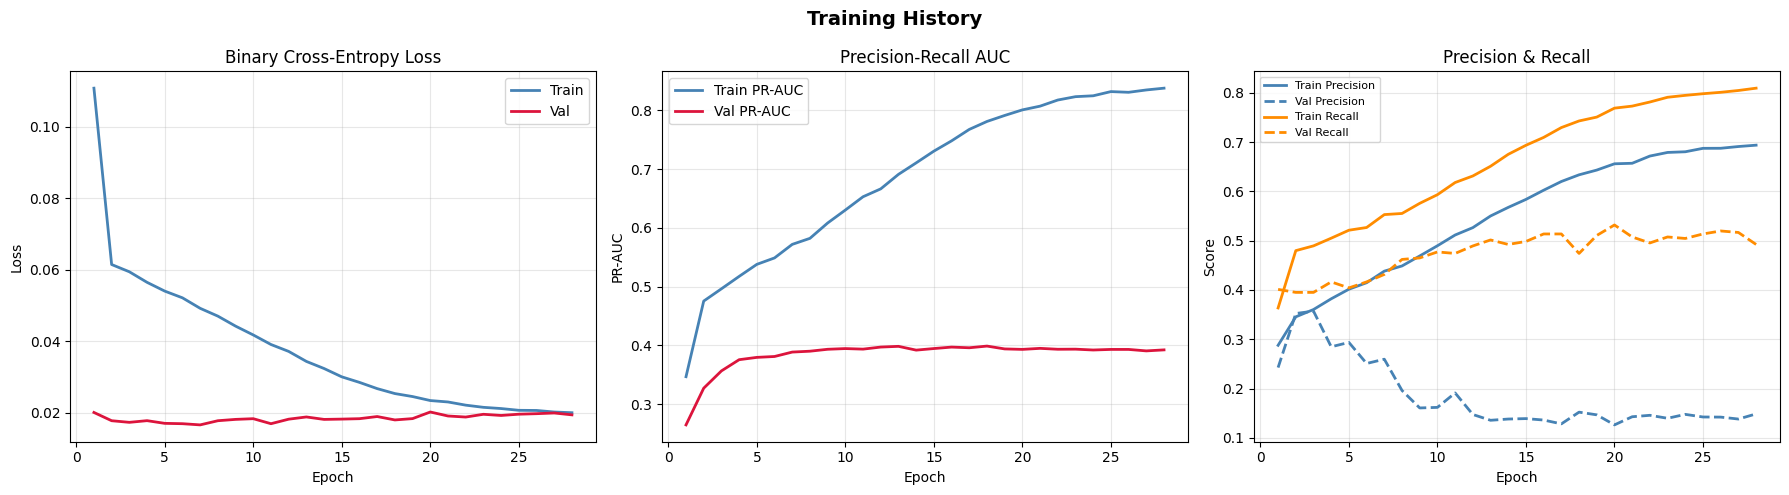

In [31]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_ran, hist['loss'],     label='Train', color='steelblue', lw=2)
axes[0].plot(epochs_ran, hist['val_loss'], label='Val',   color='crimson',   lw=2)
axes[0].set_title('Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR-AUC
axes[1].plot(epochs_ran, hist['auc'],     label='Train PR-AUC', color='steelblue', lw=2)
axes[1].plot(epochs_ran, hist['val_auc'], label='Val PR-AUC',   color='crimson',   lw=2)
axes[1].set_title('Precision-Recall AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PR-AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Precision vs Recall
axes[2].plot(epochs_ran, hist['precision'],     label='Train Precision', color='steelblue',  lw=2)
axes[2].plot(epochs_ran, hist['val_precision'], label='Val Precision',   color='steelblue',  lw=2, linestyle='--')
axes[2].plot(epochs_ran, hist['recall'],        label='Train Recall',    color='darkorange', lw=2)
axes[2].plot(epochs_ran, hist['val_recall'],    label='Val Recall',      color='darkorange', lw=2, linestyle='--')
axes[2].set_title('Precision & Recall')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Score')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. 🎯 Optimal Threshold Tuning

> Default 0.5 threshold is almost always wrong for imbalanced datasets.
> We scan thresholds from 0.05 to 0.95 and pick the one with the **highest F1 on the validation set**.

Optimal threshold : 0.80
Best Val F1       : 0.4746


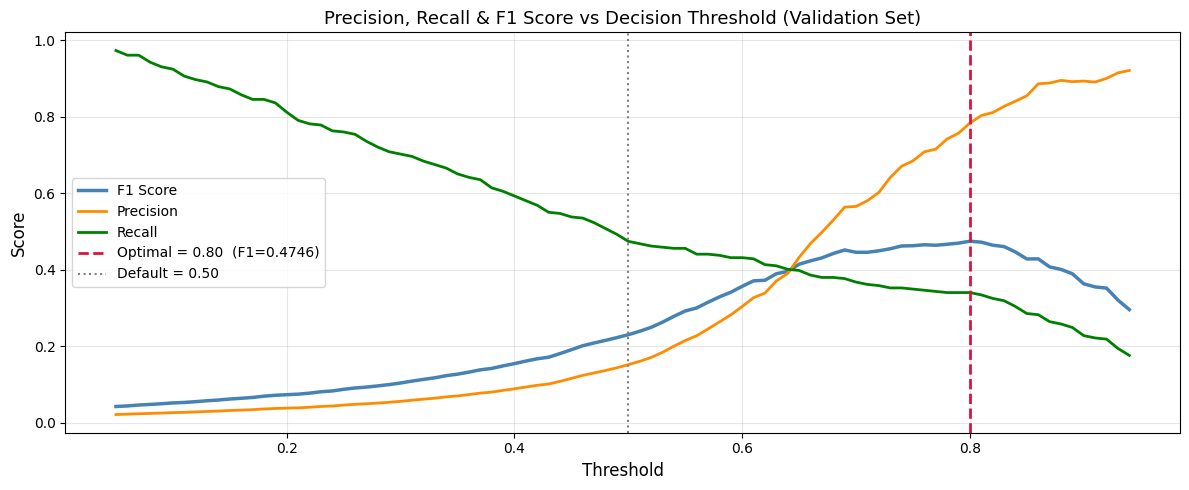

In [32]:
# Load best saved checkpoint
model = keras.models.load_model(
    'best_fraud_rnn.keras',
    custom_objects={'focal_loss_fn': focal_loss_fn}
)

# Get fraud probabilities on val set
val_probs = model.predict(X_val, batch_size=64, verbose=0).flatten()

# Scan thresholds
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = []
precision_scores = []
recall_scores = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds, zero_division=0))
    precision_scores.append(precision_score(y_val, preds, zero_division=0))
    recall_scores.append(recall_score(y_val, preds, zero_division=0))

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1_val = max(f1_scores)

print(f'Optimal threshold : {best_thresh:.2f}')
print(f'Best Val F1       : {best_f1_val:.4f}')

# Plot all three metrics
plt.figure(figsize=(12, 5))

plt.plot(thresholds, f1_scores, color='steelblue', lw=2.5, label='F1 Score')
plt.plot(thresholds, precision_scores, color='darkorange', lw=2, label='Precision')
plt.plot(thresholds, recall_scores, color='green', lw=2, label='Recall')

plt.axvline(best_thresh, color='crimson', linestyle='--', lw=2,
            label=f'Optimal = {best_thresh:.2f}  (F1={best_f1_val:.4f})')
plt.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Default = 0.50')

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision, Recall & F1 Score vs Decision Threshold (Validation Set)', fontsize=13)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning_complete.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 📊 Full Evaluation on Test Set

In [33]:
# ==============================
# VALIDATION SET EVALUATION
# ==============================
from sklearn.metrics import precision_score, recall_score, f1_score,  accuracy_score, roc_auc_score, average_precision_score, classification_report

# Predict on validation set
val_probs = model.predict(X_val, batch_size=512, verbose=0).flatten()
val_preds = (val_probs >= best_thresh).astype(int)

# Metrics
val_f1     = f1_score(y_val, val_preds)
val_auc    = roc_auc_score(y_val, val_probs)
val_pr_auc = average_precision_score(y_val, val_probs)
val_accuracy = accuracy_score(y_val, val_preds)

print('=' * 50)
print('      VALIDATION SET RESULTS')
print('=' * 50)
print(f'  Accuracy               : {val_accuracy:.4f}')
print(f'  F1 Score (fraud class) : {val_f1:.4f}')
print(f'  ROC-AUC                : {val_auc:.4f}')
print(f'  PR-AUC                 : {val_pr_auc:.4f}')
print(f'  Decision threshold     : {best_thresh:.2f}')
print('=' * 50)
print()
print('=== Classification Report ===')
print(classification_report(y_val, val_preds, target_names=['Legit', 'Fraud']))

# Threshold sweep on validation
print('\n=== Threshold Analysis (Validation) ===')
thresholds = np.arange(0.20, 1.00, 0.02)

rows = []
for thresh in thresholds:
    preds = (val_probs >= thresh).astype(int)
    p = precision_score(y_val, preds, zero_division=0)
    r = recall_score(y_val, preds, zero_division=0)
    f = f1_score(y_val, preds, zero_division=0)
    rows.append({'Threshold': f'{thresh:.2f}', 'Precision': round(p, 4), 'Recall': round(r, 4), 'F1': round(f, 4)})

df_thresh_val = pd.DataFrame(rows).set_index('Threshold')
print(df_thresh_val.to_string())

# ==============================
# TEST SET EVALUATION (same as before)
# ==============================
test_probs = model.predict(X_test, batch_size=512, verbose=0).flatten()
test_preds = (test_probs >= 0.88).astype(int)

test_f1     = f1_score(y_test, test_preds)
test_auc    = roc_auc_score(y_test, test_probs)
test_pr_auc = average_precision_score(y_test, test_probs)
test_accuracy = accuracy_score(y_test, test_preds)

print('\n' + '=' * 50)
print('         TEST SET RESULTS')
print('=' * 50)
print(f'  Accuracy               : {test_accuracy:.4f}')
print(f'  F1 Score (fraud class) : {test_f1:.4f}')
print(f'  ROC-AUC                : {test_auc:.4f}')
print(f'  PR-AUC                 : {test_pr_auc:.4f}')
print(f'  Decision threshold     : {best_thresh:.2f}')
print('=' * 50)
print()
print('=== Classification Report ===')
print(classification_report(y_test, test_preds, target_names=['Legit', 'Fraud']))

# Threshold sweep on test
print('\n=== Threshold Analysis (Test) ===')
rows = []
for thresh in thresholds:
    preds = (test_probs >= thresh).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f = f1_score(y_test, preds, zero_division=0)
    rows.append({'Threshold': f'{thresh:.2f}', 'Precision': round(p, 4), 'Recall': round(r, 4), 'F1': round(f, 4)})

df_thresh_test = pd.DataFrame(rows).set_index('Threshold')
print(df_thresh_test.to_string())

# ==============================
# Compare Val vs Test
# ==============================
print('\n' + '=' * 50)
print('    VALIDATION vs TEST COMPARISON')
print('=' * 50)

print(f'{"Metric":<15} {"Validation":>12} {"Test":>12} {"Difference":>12}')
print('-' * 50)
print(f'{"Accuracy":<15} {val_accuracy:>12.4f} {test_accuracy:>12.4f} {test_accuracy-val_accuracy:>12.4f}')
print(f'{"ROC-AUC":<15} {val_auc:>12.4f} {test_auc:>12.4f} {test_auc-val_auc:>12.4f}')
print(f'{"PR-AUC":<15} {val_pr_auc:>12.4f} {test_pr_auc:>12.4f} {test_pr_auc-val_pr_auc:>12.4f}')
print(f'{"F1 Score":<15} {val_f1:>12.4f} {test_f1:>12.4f} {test_f1-val_f1:>12.4f}')
print('=' * 50)

      VALIDATION SET RESULTS
  Accuracy               : 0.9843
  F1 Score (fraud class) : 0.4746
  ROC-AUC                : 0.8015
  PR-AUC                 : 0.3993
  Decision threshold     : 0.80

=== Classification Report ===
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99     15472
       Fraud       0.78      0.34      0.47       329

    accuracy                           0.98     15801
   macro avg       0.88      0.67      0.73     15801
weighted avg       0.98      0.98      0.98     15801


=== Threshold Analysis (Validation) ===
           Precision  Recall      F1
Threshold                           
0.20          0.0386  0.8116  0.0737
0.22          0.0409  0.7812  0.0777
0.24          0.0441  0.7629  0.0835
0.26          0.0485  0.7538  0.0912
0.28          0.0518  0.7204  0.0967
0.30          0.0563  0.7021  0.1043
0.32          0.0619  0.6839  0.1136
0.34          0.0680  0.6657  0.1234
0.36          0.0740  0.6413  0.13

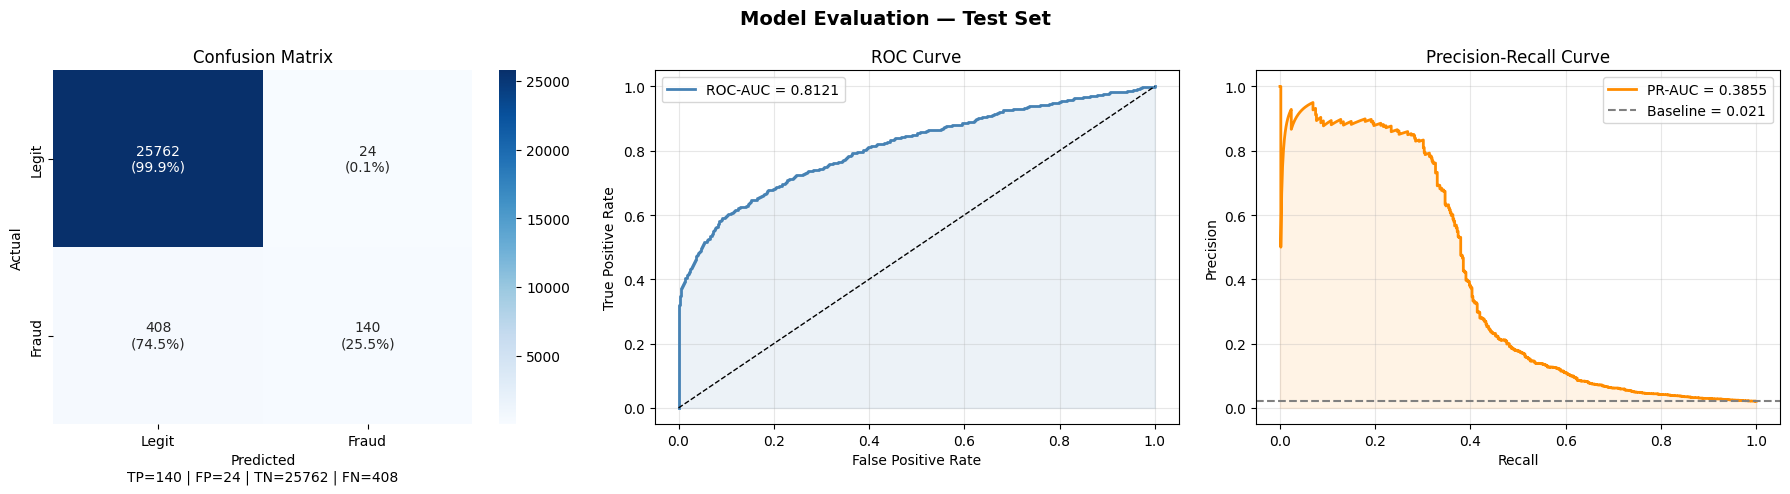

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation — Test Set', fontsize=14, fontweight='bold')

# Confusion Matrix with counts + percentages
cm = confusion_matrix(y_test, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(rv, rp)]
                   for rv, rp in zip(cm, cm_pct)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
tn, fp, fn, tp = cm.ravel()
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel(f'Predicted\nTP={tp} | FP={fp} | TN={tn} | FN={fn}')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {test_auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, test_probs)
axes[2].plot(recall, precision, color='darkorange', lw=2, label=f'PR-AUC = {test_pr_auc:.4f}')
axes[2].axhline(y_test.mean(), color='gray', linestyle='--', lw=1.5,
                label=f'Baseline = {y_test.mean():.3f}')
axes[2].fill_between(recall, precision, alpha=0.1, color='darkorange')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

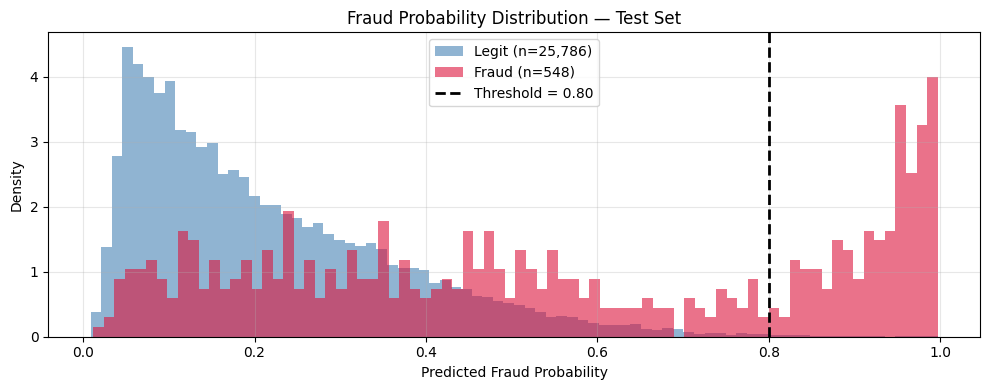

In [35]:
# Fraud probability distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(test_probs[y_test == 0], bins=80, alpha=0.6, color='steelblue',
        label=f'Legit (n={int((y_test==0).sum()):,})', density=True)
ax.hist(test_probs[y_test == 1], bins=80, alpha=0.6, color='crimson',
        label=f'Fraud (n={int(y_test.sum()):,})', density=True)
ax.axvline(best_thresh, color='black', linestyle='--', lw=2,
           label=f'Threshold = {best_thresh:.2f}')
ax.set_xlabel('Predicted Fraud Probability')
ax.set_ylabel('Density')
ax.set_title('Fraud Probability Distribution — Test Set')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('=== Label Consistency Check ===\n')

# Check 1: FAILED status should have high fraud rate
print('Fraud rate by status:')
print(df.groupby('status')['is_fraud'].agg(['sum', 'count', 'mean']).round(4))

# Check 2: P2P should have higher fraud than P2M
print('\nFraud rate by transaction type:')
print(df.groupby('transaction_type')['is_fraud'].agg(['sum', 'count', 'mean']).round(4))

# Check 3: Are fraud labels correlated with engineered fraud flags?
print('\nFraud rate by is_amount_spike:')
print(df.groupby('is_amount_spike')['is_fraud'].agg(['sum', 'count', 'mean']).round(4))

print('\nFraud rate by is_location_jump:')
print(df.groupby('is_location_jump')['is_fraud'].agg(['sum', 'count', 'mean']).round(4))

# Check 4: Look at a few fraud examples
print('\n=== Sample of Labeled Fraud Cases ===')
fraud_samples = df[df['is_fraud'] == 1].sample(10, random_state=42)
print(fraud_samples[['timestamp', 'amount', 'transaction_type', 'status',
                      'is_amount_spike', 'is_location_jump', 'distance_from_prev_tx']])

=== Label Consistency Check ===

Fraud rate by status:
          sum   count    mean
status                       
FAILED    382    3355  0.1139
SUCCESS  2749  148313  0.0185

Fraud rate by transaction type:
                   sum  count    mean
transaction_type                     
Bill Payment       131  14995  0.0087
P2M                299  30208  0.0099
P2P               2564  91557  0.0280
Recharge           137  14908  0.0092

Fraud rate by is_amount_spike:
                  sum   count    mean
is_amount_spike                      
0                2238  137437  0.0163
1                 893   14231  0.0628

Fraud rate by is_location_jump:
                   sum   count    mean
is_location_jump                      
0                 2574  150564  0.0171
1                  557    1104  0.5045

=== Sample of Labeled Fraud Cases ===
                 timestamp    amount transaction_type   status  \
84042  2025-01-07 23:57:05  0.030958              P2P  SUCCESS   
124927 2025-01-26 00

---
## 12. 💾 Save Model & Artifacts

In [ ]:
# Define the base path for saving in Google Drive
DRIVE_SAVE_PATH = '/content/drive/My Drive/Colab Notebooks/Final Models/LSTM/IMPROVED MODEL'

# Save Keras model
model.save(os.path.join(DRIVE_SAVE_PATH, 'upi_fraud_lstm_updated.keras'))

# Save scaler
with open(os.path.join(DRIVE_SAVE_PATH, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save label encoders
with open(os.path.join(DRIVE_SAVE_PATH, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump(label_encoders, f)

# Save config
# NUM_FEATURES is not defined, will get it from X_train.shape[2]
NUM_FEATURES = X_train.shape[2]
model_config = {
    'seq_len'      : SEQ_LEN,
    'num_features' : NUM_FEATURES,
    'feature_cols' : FEATURE_COLS,
    'threshold'    : float(best_thresh),
    'test_f1'      : float(test_f1),
    'test_auc'     : float(test_auc),
    'test_pr_auc'  : float(test_pr_auc),
    'label_col'    : LABEL_COL,
}
with open(os.path.join(DRIVE_SAVE_PATH, 'model_config.pkl'), 'wb') as f:
    pickle.dump(model_config, f)

print(f'All artifacts saved to: {DRIVE_SAVE_PATH}')
print('  upi_fraud_rnn_final.keras  - trained SimpleRNN model')
print('  scaler.pkl                 - fitted StandardScaler')
print('  label_encoders.pkl         - fitted LabelEncoders')
print('  model_config.pkl           - config, threshold, metrics')
print()
print('Final Results:')
print(f'  F1 Score : {test_f1:.4f}')
print(f'  ROC-AUC  : {test_auc:.4f}')
print(f'  PR-AUC   : {test_pr_auc:.4f}')
print(f'  Threshold: {best_thresh:.2f}')

All artifacts saved to: /content/drive/My Drive/Colab Notebooks/Final Models/LSTM/IMPROVED MODEL
  upi_fraud_rnn_final.keras  - trained SimpleRNN model
  scaler.pkl                 - fitted StandardScaler
  label_encoders.pkl         - fitted LabelEncoders
  model_config.pkl           - config, threshold, metrics

Final Results:
  F1 Score : 0.4684
  ROC-AUC  : 0.8368
  PR-AUC   : 0.4514
  Threshold: 0.84


In [ ]:
import json
import numpy as np
from datetime import datetime

# Define the base path for saving in Google Drive
DRIVE_SAVE_PATH = '/content/drive/My Drive/Colab Notebooks/Final Models/LSTM/IMPROVED MODEL/JSON DATA'

# ═══════════════════════════════════════════════════════════════════════════
# SAVE ALL ARTIFACTS AS JSON
# ═══════════════════════════════════════════════════════════════════════════

print('Saving model artifacts as JSON...')

# ─────────────────────────────────────────────────────────────────────────────
# 1. Test Predictions (for regenerating curves)
# ─────────────────────────────────────────────────────────────────────────────
test_predictions_json = {
    'y_test': y_test.tolist(),  # convert numpy to list
    'y_pred_proba': test_probs.tolist(),
    'y_pred_binary': test_preds.tolist(),
    'threshold': float(best_thresh),
    'num_samples': int(len(y_test)),
    'num_fraud': int(y_test.sum()),
    'num_legit': int((y_test == 0).sum())
}

with open(os.path.join(DRIVE_SAVE_PATH, 'test_predictions.json'), 'w') as f:
    json.dump(test_predictions_json, f, indent=2)

print('✅ test_predictions.json       — predictions for curve regeneration')

# ─────────────────────────────────────────────────────────────────────────────
# 2. Performance Metrics
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

tp = int(((test_preds == 1) & (y_test == 1)).sum())
fp = int(((test_preds == 1) & (y_test == 0)).sum())
tn = int(((test_preds == 0) & (y_test == 0)).sum())
fn = int(((test_preds == 0) & (y_test == 1)).sum())

performance_metrics = {
    'model_info': {
        'total_parameters': int(model.count_params()),
        'evaluation_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    },
    'test_set_metrics': {
        'accuracy': float(accuracy_score(y_test, test_preds)),
        'roc_auc': float(test_auc),
        'pr_auc': float(test_pr_auc),
        'f1_score': float(test_f1),
        'precision': float(precision_score(y_test, test_preds)),
        'recall': float(recall_score(y_test, test_preds)),
        'optimal_threshold': float(best_thresh)
    },
    'confusion_matrix': {
        'true_positives': tp,
        'false_positives': fp,
        'true_negatives': tn,
        'false_negatives': fn,
        'total_samples': int(len(y_test))
    },
    'class_distribution': {
        'fraud_cases': int(y_test.sum()),
        'legit_cases': int((y_test == 0).sum()),
        'fraud_rate': float(y_test.mean())
    }
}

with open(os.path.join(DRIVE_SAVE_PATH, 'performance_metrics.json'), 'w') as f:
    json.dump(performance_metrics, f, indent=2)

print('✅ performance_metrics.json    — final metrics (human-readable)')

# ─────────────────────────────────────────────────────────────────────────────
# 3. Model Configuration
# ─────────────────────────────────────────────────────────────────────────────
model_config_json = {
    'data_config': {
        'seq_len': int(SEQ_LEN),
        'num_features': int(len(FEATURE_COLS)),
        'feature_columns': FEATURE_COLS,
        'label_column': 'is_fraud',
        'train_samples': int(len(X_train)),
        'val_samples': int(len(X_val)),
        'test_samples': int(len(X_test))
    },
    'model_architecture': {
        'type': 'Simple RNN',
        'layers': [
            {'name': 'LSTM', 'units': 128, 'return_sequences': False},
            {'name': 'Dense', 'units': 32, 'activation': 'relu'},
            {'name': 'Dropout', 'rate': 0.3},
            {'name': 'Dense', 'units': 1, 'activation': 'sigmoid'}
        ],
        'total_parameters': int(model.count_params())
    },
    'training_config': {
        'loss_function': 'Binary Focal Loss',
        'focal_gamma': 2.0,
        'focal_alpha': 0.75,
        'optimizer': 'Adam',
        'learning_rate': 0.0003,
        'batch_size': 256,
        'stratified_batching': True,
        'fraud_per_batch': 38,
        'legit_per_batch': 218,
        'epochs': 50,
        'early_stopping_patience': 10,
        'initial_bias': float(initial_bias[0])
    },
    'preprocessing': {
        'categorical_encoding': 'LabelEncoder',
        'numeric_scaling': 'StandardScaler (continuous features only)',
        'binary_flags_preserved': ['is_amount_spike', 'is_location_jump', 'is_weekend', 'is_night', 'isp_changed']
    }
}

with open(os.path.join(DRIVE_SAVE_PATH, 'model_config.json'), 'w') as f:
    json.dump(model_config_json, f, indent=2)

print('✅ model_config.json           — architecture & hyperparameters')

# ─────────────────────────────────────────────────────────────────────────────
# 4. Training History (loss/metrics over epochs)
# ─────────────────────────────────────────────────────────────────────────────
training_history_json = {
    'epochs_trained': len(history.history['loss']),
    'metrics_per_epoch': {
        'train_loss': [float(x) for x in history.history['loss']],
        'val_loss': [float(x) for x in history.history['val_loss']],
        'train_auc': [float(x) for x in history.history['auc']],
        'val_auc': [float(x) for x in history.history['val_auc']],
        'train_precision': [float(x) for x in history.history['precision']],
        'val_precision': [float(x) for x in history.history['val_precision']],
        'train_recall': [float(x) for x in history.history['recall']],
        'val_recall': [float(x) for x in history.history['val_recall']]
    },
    'best_epoch': {
        'epoch_number': int(np.argmax(history.history['val_auc'])) + 1,
        'val_auc': float(max(history.history['val_auc']))
    }
}

with open(os.path.join(DRIVE_SAVE_PATH, 'training_history.json'), 'w') as f:
    json.dump(training_history_json, f, indent=2)

print('✅ training_history.json       — loss/metrics over epochs')

# ─────────────────────────────────────────────────────────────────────────────
# 5. Threshold Analysis (F1 scores at different thresholds)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, f1_score

# Compute F1 at different thresholds
thresholds_to_test = np.arange(0.1, 1.0, 0.05)
threshold_analysis = []

for thresh in thresholds_to_test:
    preds_at_thresh = (test_probs >= thresh).astype(int)
    if preds_at_thresh.sum() > 0:  # avoid division by zero
        prec = float(precision_score(y_test, preds_at_thresh, zero_division=0))
        rec = float(recall_score(y_test, preds_at_thresh, zero_division=0))
        f1 = float(f1_score(y_test, preds_at_thresh, zero_division=0))
    else:
        prec = rec = f1 = 0.0

    threshold_analysis.append({
        'threshold': float(thresh),
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    })

threshold_data = {
    'optimal_threshold': float(best_thresh),
    'optimal_f1': float(max([x['f1_score'] for x in threshold_analysis])),
    'threshold_sweep': threshold_analysis
}

with open(os.path.join(DRIVE_SAVE_PATH, 'threshold_analysis.json'), 'w') as f:
    json.dump(threshold_data, f, indent=2)

print('✅ threshold_analysis.json     — F1/precision/recall at different thresholds')

# ─────────────────────────────────────────────────────────────────────────────
# 6. Summary Report
# ─────────────────────────────────────────────────────────────────────────────
summary = {
    'project': 'UPI Fraud Detection',
    'model_version': '1.0 - simple RNN',
    'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'files_saved': [
        'best_fraud_rnn.keras',
        'scaler.pkl',
        'label_encoders.pkl',
        'test_predictions.json',
        'performance_metrics.json',
        'model_config.json',
        'training_history.json',
        'threshold_analysis.json'
    ],
    'key_results': {
        'roc_auc': float(test_auc),
        'pr_auc': float(test_pr_auc),
        'f1_score': float(test_f1),
        'recall': float(recall_score(y_test, test_preds)),
        'precision': float(precision_score(y_test, test_preds)),
        'fraud_caught': tp,
        'fraud_missed': fn,
        'false_alarms': fp
    },
    'improvement_over_baseline': {
        'baseline_model': 'SimpleRNN with 64 units',
        'baseline_roc_auc': 0.7669,
        'lstm_roc_auc': float(test_auc),
        'improvement': f'+{((test_auc - 0.7669) / 0.7669 * 100):.1f}%'
    }
}

with open(os.path.join(DRIVE_SAVE_PATH, 'model_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ model_summary.json          — executive summary\n')

print('='*60)
print('ALL JSON FILES SAVED SUCCESSFULLY')
print('='*60)

Saving model artifacts as JSON...
✅ test_predictions.json       — predictions for curve regeneration
✅ performance_metrics.json    — final metrics (human-readable)
✅ model_config.json           — architecture & hyperparameters
✅ training_history.json       — loss/metrics over epochs
✅ threshold_analysis.json     — F1/precision/recall at different thresholds
✅ model_summary.json          — executive summary

ALL JSON FILES SAVED SUCCESSFULLY


In [ ]:

# How to reload everything in a new session
loaded_model = keras.models.load_model('upi_fraud_rnn_final.keras')

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('label_encoders.pkl', 'rb') as f:
    loaded_encoders = pickle.load(f)

with open('model_config.pkl', 'rb') as f:
    cfg = pickle.load(f)

print('Reloaded successfully')
print(f"Threshold  : {cfg['threshold']}")
print(f"Features   : {len(cfg['feature_cols'])}")
print(f"Test F1    : {cfg['test_f1']:.4f}")
print(f"Test AUC   : {cfg['test_auc']:.4f}")

---
## 11. 🔄 Batch Prediction on New Data

In [ ]:
def batch_predict(model, new_df, feature_cols, label_encoders, scaler,
                  seq_len, threshold, label_col=None):
    """
    Run batch fraud prediction on any new dataframe with same schema.

    Returns original dataframe with 3 new columns:
        fraud_probability : float [0, 1]
        fraud_predicted   : int   {0, 1}
        risk_level        : str   {Low, Medium, High, Critical}
    """
    df_new = new_df.copy()
    df_new = df_new.sort_values(['user_upi_id', 'timestamp']).reset_index(drop=True)

    # Apply same preprocessing pipeline
    df_new['merchant_id']       = df_new['merchant_id'].fillna('none')
    df_new['merchant_category'] = df_new['merchant_category'].fillna('none')

    df_new['hour']        = df_new['timestamp'].dt.hour
    df_new['day_of_week'] = df_new['timestamp'].dt.dayofweek
    df_new['is_weekend']  = df_new['day_of_week'].isin([5, 6]).astype(int)
    df_new['is_night']    = ((df_new['hour'] >= 22) | (df_new['hour'] <= 5)).astype(int)

    for col, le in label_encoders.items():
        df_new[col + '_enc'] = df_new[col].astype(str).map(
            lambda x, le=le: le.transform([x])[0] if x in le.classes_ else 0
        )

    df_new['rolling_mean_amount'] = df_new.groupby('user_upi_id')['amount'].transform(
        lambda x: x.shift(1).expanding().mean().fillna(x.mean())
    )
    df_new['rolling_std_amount'] = df_new.groupby('user_upi_id')['amount'].transform(
        lambda x: x.shift(1).expanding().std().fillna(x.std())
    )
    df_new['amount_vs_personal_mean'] = df_new['amount'] - df_new['rolling_mean_amount']
    df_new['user_tx_rank'] = df_new.groupby('user_upi_id').cumcount()

    if 'device_changed' in df_new.columns:
        df_new.drop(columns=['device_changed'], inplace=True)

    df_new[feature_cols] = scaler.transform(df_new[feature_cols].fillna(0))

    # Build sequences
    X_new, original_indices = [], []
    for user_id, group in df_new.groupby('user_upi_id', sort=False):
        feats   = group[feature_cols].values.astype(np.float32)
        indices = group.index.tolist()
        for i in range(seq_len, len(feats)):
            X_new.append(feats[i - seq_len : i])
            original_indices.append(indices[i])

    X_new = np.array(X_new, dtype=np.float32)

    # Predict
    probs = model.predict(X_new, batch_size=512, verbose=0).flatten()
    preds = (probs >= threshold).astype(int)

    # Risk bucketing
    risk_level = pd.cut(
        probs,
        bins   = [0, 0.3, 0.6, 0.8, 1.01],
        labels = ['Low', 'Medium', 'High', 'Critical']
    )

    results = new_df.loc[original_indices].copy()
    results['fraud_probability'] = probs.round(4)
    results['fraud_predicted']   = preds
    results['risk_level']        = risk_level

    print(f'Processed     : {len(results):,} transactions')
    print(f'Fraud flagged : {preds.sum():,} ({preds.mean()*100:.2f}%)')
    print(f'\nRisk level distribution:')
    print(results['risk_level'].value_counts())

    if label_col and label_col in results.columns:
        print(f'\n=== Performance Metrics ===')
        print(classification_report(results[label_col], preds,
                                    target_names=['Legit', 'Fraud']))
    return results


# Demo: run on first 100 users from raw data
df_raw    = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
demo_users = df_raw['user_upi_id'].unique()[:100]
df_demo   = df_raw[df_raw['user_upi_id'].isin(demo_users)].copy()

print('Running batch prediction on 100 users...\n')
results_df = batch_predict(
    model          = model,
    new_df         = df_demo,
    feature_cols   = FEATURE_COLS,
    label_encoders = label_encoders,
    scaler         = scaler,
    seq_len        = SEQ_LEN,
    threshold      = best_thresh,
    label_col      = LABEL_COL
)

print('\n=== Top 10 Highest Risk Transactions ===')
results_df.sort_values('fraud_probability', ascending=False)[[
    'timestamp', 'user_upi_id', 'amount', 'transaction_type',
    'status', 'fraud_probability', 'risk_level', LABEL_COL
]].head(10)

---
## 📝 Notes & Next Steps

| Area | Detail |
|------|--------|
| **Primary metric** | F1 Score — balanced precision/recall for 47:1 imbalance |
| **Imbalance strategy** | Weighted binary crossentropy — fraud penalized ~24x more |
| **Top signals** | status=FAILED (11.4% fraud rate), transaction_type=P2P (2.8%) |
| **Dropped column** | device_changed — all zeros, zero predictive value |
| **Threshold** | Auto-tuned on validation set to maximize F1 |
| **Risk levels** | Low (<0.3), Medium (0.3-0.6), High (0.6-0.8), Critical (>0.8) |
| **Upgrade path** | Swap SimpleRNN for LSTM or GRU layers for better performance |